In [35]:
"""
Difference-in-Differences Analysis: Fire Effects on Recreation
Estimates how wildfires and prescribed fires affect recreational visitation
using two-way fixed effects regression.
"""

import pandas as pd
import numpy as np
import re

# ============================================================
# YOUR DATA FILES
# ============================================================

# Colorado data (contains predictions + features)
CO_DATA = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\GitHub\Data\TreatCon_Pred_CO.csv"

# California data (contains predictions + features)
CA_DATA = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\GitHub\Data\TreatCon_Pred_CA.csv"

# Output path
OUTPUT = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\did_results.csv"

# ============================================================
# ANALYSIS SETTINGS
# ============================================================

MONTHS_PRE_FIRE = 12           # Include 12 months before fire
REFERENCE_MONTH = -2           # Set month -2 as baseline (=0)
MIN_SAMPLE_PERCENT = 0.10      # Drop months with <10% of max sample (months towards the 5-year mark with very little data)

# Control variables (only time-varying ones - site FE handles time-invariant)
CONTROLS = ['temperature_mean']  # Temperature is time-varying confounder that

# Note: Trail density, slope, vegetation are time-invariant and already 
# controlled for by site fixed effects. Including them would be redundant.

# ============================================================
# CLASSIFY TREATMENT STATUS
# ============================================================

def classify_treatment(treatment_type, state):
    """
    Classify sites as wildfire/prescribed fire × treated/control
    
    Returns: 'wildfire_treated', 'wildfire_control', 'rx_treated', 'rx_control'
    """
    if pd.isna(treatment_type):
        return 'unknown'
    
    tt = str(treatment_type).lower()
    
    if state == 'CO':
        # Colorado labels: "fire", "controlfire", "rx", "controlrx"
        if 'fire' in tt and 'control' not in tt:
            return 'wildfire_treated'
        elif 'controlfire' in tt:
            return 'wildfire_control'
        elif 'rx' in tt and 'control' not in tt:
            return 'rx_treated'
        elif 'controlrx' in tt:
            return 'rx_control'
    else:
        # California labels: "wildfire_treated", "wildfire_control", etc.
        if 'wildfire' in tt and 'treated' in tt:
            return 'wildfire_treated'
        elif 'wildfire' in tt and 'control' in tt:
            return 'wildfire_control'
        elif 'rx' in tt and 'treated' in tt:
            return 'rx_treated'
        elif 'rx' in tt and 'control' in tt:
            return 'rx_control'
    
    return 'unknown'

# ============================================================
# DiD ESTIMATION
# ============================================================

def estimate_fire_effect(data, fire_type, controls):
    """
    Estimate fire effects using two-way fixed effects (TWFE) DiD
    
    Parameters:
    -----------
    data : DataFrame with columns [siteid, year, month, rel_month, outcome, treated, time_period]
    fire_type : 'wildfire' or 'prescribed'
    controls : list of control variable names
    
    Returns:
    --------
    monthly_effects : dict of {month: {'coef', 'se', 'ci_lower', 'ci_upper', 'n_treated'}}
    n_treated : number of treated sites
    n_control : number of control sites
    baseline : pre-fire average outcome for treated sites
    """
    try:
        import pyfixest as pf
    except ImportError:
        raise ImportError("Install pyfixest: pip install pyfixest")
    
    # Filter to relevant fire type
    if fire_type == 'wildfire':
        df = data[data['treatment_group'].isin(['wildfire_treated', 'wildfire_control'])].copy()
    else:
        df = data[data['treatment_group'].isin(['rx_treated', 'rx_control'])].copy()
    
    # Keep analysis window (12 months before fire onwards)
    df = df[df['rel_month'].notna()].copy()
    df = df[df['rel_month'] >= -MONTHS_PRE_FIRE].copy()
    df['rel_month'] = df['rel_month'].astype(int)
    
    # Count sites
    n_treated = df[df['treated'] == 1]['siteid'].nunique()
    n_control = df[df['treated'] == 0]['siteid'].nunique()
    
    if n_treated < 2 or n_control < 1:
        return None, None, None, None
    
    # Calculate baseline (pre-fire average for treated sites)
    baseline = df[(df['treated'] == 1) & (df['rel_month'] < 0)]['outcome'].mean()
    if pd.isna(baseline) or baseline == 0:
        baseline = df['outcome'].mean()
    
    # Build regression formula: outcome ~ treatment×month + controls | site + time FE
    available_controls = [c for c in controls if c in df.columns]
    control_term = " + ".join(available_controls) if available_controls else "1"
    formula = f"outcome ~ i(rel_month, treated, ref={REFERENCE_MONTH}) + {control_term} | siteid + time_period"
    
    # Run TWFE regression with robust standard errors
    model = pf.feols(formula, data=df, vcov='HC1')
    coefficients = model.coef().to_dict()
    std_errors = model.se().to_dict()
    
    # Extract monthly effects and sample sizes
    n_treated_by_month = df[df['treated'] == 1].groupby('rel_month')['siteid'].nunique().to_dict()
    
    effects = {}
    for param_name in coefficients.keys():
        match = re.search(r'\[(-?\d+)\]:treated', str(param_name))
        if match:
            month = int(match.group(1))
            coef = float(coefficients[param_name])
            se = float(std_errors[param_name])
            
            effects[month] = {
                'coef': coef,
                'se': se,
                'ci_lower': coef - 1.96 * se,
                'ci_upper': coef + 1.96 * se,
                'n_treated': n_treated_by_month.get(month, 0)
            }
    
    # Add reference month (set to zero by definition)
    effects[REFERENCE_MONTH] = {
        'coef': 0.0, 'se': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0, 'n_treated': 0
    }
    
    return dict(sorted(effects.items())), n_treated, n_control, baseline


def aggregate_to_years(monthly_effects):
    """
    Aggregate monthly effects to annual using inverse-variance weighting
    
    Groups months into years:
    - Month 0-11 → Year 1
    - Month 12-23 → Year 2
    - Month 24-35 → Year 3
    - etc.
    
    Drops months where treated sample falls below 10% of peak.
    """
    if not monthly_effects:
        return None
    
    df = pd.DataFrame.from_dict(monthly_effects, orient='index')
    
    # Find minimum acceptable sample (10% of peak across all months)
    peak_sample = df['n_treated'].max()
    min_sample = max(1, int(np.floor(peak_sample * MIN_SAMPLE_PERCENT)))
    
    # Keep only post-fire months with sufficient sample
    df = df[df.index >= 0]
    df = df[df['n_treated'] >= min_sample]
    
    if len(df) == 0:
        return None
    
    # Assign months to years
    df['year'] = np.floor(df.index / 12).astype(int) + 1
    df.loc[df['year'] > 5, 'year'] = 5  # Cap at year 5+
    
    # Aggregate by year using inverse-variance weights
    annual = []
    for year, group in df.groupby('year'):
        # Weight by precision (1/variance)
        weights = 1 / (group['se']**2 + 1e-10)
        weights = weights / weights.sum()
        
        # Weighted average
        coef = (group['coef'] * weights).sum()
        se = 1 / np.sqrt((1 / (group['se']**2 + 1e-10)).sum())
        
        annual.append({
            'year': int(year),
            'coef': coef,
            'se': se,
            'ci_lower': coef - 1.96 * se,
            'ci_upper': coef + 1.96 * se
        })
    
    # Add year 0 (reference)
    annual.insert(0, {
        'year': 0, 'coef': 0.0, 'se': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0
    })
    
    return {row['year']: row for row in annual}


def to_percent(effects, baseline):
    """Convert raw coefficients to percentage changes"""
    if baseline == 0:
        return effects
    
    return {
        year: {
            'coef': (vals['coef'] / baseline) * 100,
            'se': (vals['se'] / baseline) * 100,
            'ci_lower': (vals['ci_lower'] / baseline) * 100,
            'ci_upper': (vals['ci_upper'] / baseline) * 100
        }
        for year, vals in effects.items()
    }

# ============================================================
# LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

def load_state_data(data_file, controls, state_name):
    """Load data file (already has predictions + features merged)"""
    # Load file
    df = pd.read_csv(data_file)
    df.columns = df.columns.str.strip().str.lower()
    
    # Classify treatment status
    df['treatment_group'] = df['treatment_type'].apply(lambda x: classify_treatment(x, state_name))
    df['treated'] = df['treatment_group'].str.contains('treated').astype(int)
    
    # Create outcome and time period
    df['outcome'] = df['y_pred']
    df['time_period'] = df['year'].astype(str) + '_' + df['month'].astype(str).str.zfill(2)
    
    # Fill missing controls with median
    for col in controls:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    
    return df

# Load Colorado
print("\nColorado:")
co_data = load_state_data(CO_DATA, CONTROLS, 'CO')
print(f"  {len(co_data):,} observations, {co_data['siteid'].nunique()} sites")

# Load California
print("\nCalifornia:")
ca_data = load_state_data(CA_DATA, CONTROLS, 'CA')
print(f"  {len(ca_data):,} observations, {ca_data['siteid'].nunique()} sites")

# ============================================================
# RUN ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("ESTIMATING FIRE EFFECTS")
print("=" * 60)

results = []

for state, data in [('CO', co_data), ('CA', ca_data)]:
    
    print(f"\n{state}:")
    
    for fire_type in ['wildfire', 'prescribed']:
        print(f"  {fire_type}...", end=' ')
        
        # Estimate monthly effects
        monthly, n_treat, n_control, baseline = estimate_fire_effect(data, fire_type, CONTROLS)
        
        if monthly:
            # Aggregate to years
            annual = aggregate_to_years(monthly)
            
            if annual:
                # Convert to percentage changes
                annual_pct = to_percent(annual, baseline)
                
                # Save results
                for year, vals in annual_pct.items():
                    results.append({
                        'state': state,
                        'fire_type': fire_type,
                        'year': year,
                        'effect_pct': vals['coef'],
                        'ci_lower': vals['ci_lower'],
                        'ci_upper': vals['ci_upper'],
                        'n_treated': n_treat,
                        'n_control': n_control
                    })
                
                print(f"✓ ({n_treat} treated, {n_control} control)")
            else:
                print("insufficient data")
        else:
            print("failed")

# ============================================================
# SAVE & SUMMARIZE
# ============================================================

print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

# Save to CSV
df_results = pd.DataFrame(results)
df_results.to_csv(OUTPUT, index=False)
print(f"\n✓ Saved to: {OUTPUT}")

# Print Year 1 effects
print("\nYear 1 Post-Fire Effects:")
print("-" * 60)

year1 = df_results[df_results['year'] == 1]

for state in ['CO', 'CA']:
    state_name = 'Colorado' if state == 'CO' else 'California'
    print(f"\n{state_name}:")
    
    for fire_type in ['wildfire', 'prescribed']:
        row = year1[(year1['state'] == state) & (year1['fire_type'] == fire_type)]
        
        if len(row) > 0:
            row = row.iloc[0]
            print(f"  {fire_type.capitalize():12s}: {row['effect_pct']:+6.1f}% "
                  f"(95% CI: {row['ci_lower']:+6.1f}% to {row['ci_upper']:+6.1f}%)")
            print(f"                 n={row['n_treated']} treated, {row['n_control']} control")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

LOADING DATA

Colorado:
  8,160 observations, 136 sites

California:
  22,380 observations, 373 sites

ESTIMATING FIRE EFFECTS

CO:
  wildfire... ✓ (44 treated, 40 control)
  prescribed... ✓ (22 treated, 22 control)

CA:
  wildfire... ✓ (141 treated, 142 control)
  prescribed... ✓ (32 treated, 35 control)

RESULTS

✓ Saved to: C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\did_results.csv

Year 1 Post-Fire Effects:
------------------------------------------------------------

Colorado:
  Wildfire    :  -15.1% (95% CI:  -18.5% to  -11.7%)
                 n=44 treated, 40 control
  Prescribed  :   +5.1% (95% CI:   +2.1% to   +8.1%)
                 n=22 treated, 22 control

California:
  Wildfire    :  -18.3% (95% CI:  -22.5% to  -14.0%)
                 n=141 treated, 142 control
  Prescribed  :   +1.6% (95% CI:   -0.5% to   +3.7%)
                 n=32 treated, 35 control

DONE


Loading results...
  Loaded 24 rows

Creating figure...


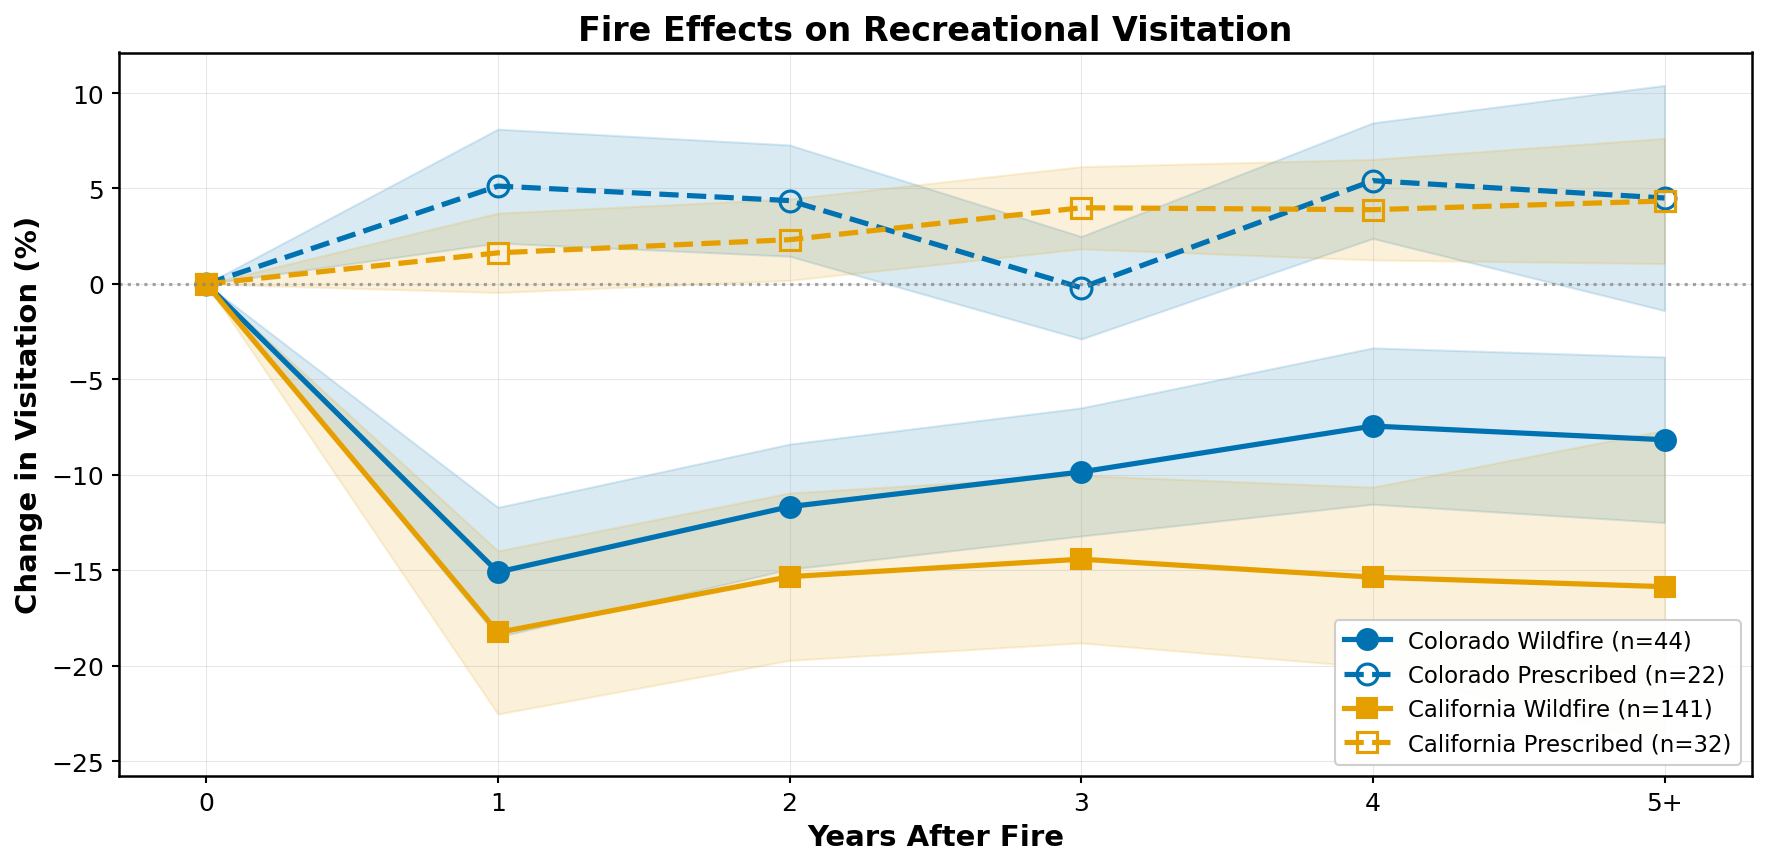


Saving figure...


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 27 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'F', 'R', 'V', 'Y', 'a', 'c', 'e', 'f', 'g', 'h', 'i', 'l', 'n', 'nonmarkingreturn', 'o', 'parenleft', 'parenright', 'percent', 'r', 's', 'space', 't']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 36, 38, 40, 41, 53, 57, 60, 68, 70, 72, 73, 74, 75, 76, 79, 81, 82, 85, 86, 87]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 32 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'E', 'F', 'R', 'V', 'Y', 'a', 'c', 'e', 'f', 'fi', 'fl', 'g

  ✓ C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\fire_effects.png
  ✓ C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\fire_effects.pdf

KEY RESULTS (Year 1)

Colorado:
  Wildfire    :  -15.1% ( -18.5% to  -11.7%) ***
  Prescribed  :   +5.1% (  +2.1% to   +8.1%) ***

California:
  Wildfire    :  -18.3% ( -22.5% to  -14.0%) ***
  Prescribed  :   +1.6% (  -0.5% to   +3.7%) 

*** = 95% confidence interval excludes zero

DONE


In [37]:
"""
Plot Fire Effects on Recreation
================================
Creates publication-ready figure showing how fires affect visitation over time.

Requires: results CSV from did_simple_clean.py
"""

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

# Where is your results file?
RESULTS_CSV = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\did_results.csv"

# Where to save figure?
OUTPUT_PNG = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\fire_effects.png"
OUTPUT_PDF = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\fire_effects.pdf"

# Figure size (width, height in inches)
FIGURE_SIZE = (12, 6)

# Colors (colorblind-friendly)
COLORS = {
    'CO': '#0072B2',  # Blue for Colorado
    'CA': '#E69F00',  # Orange for California
}

# ============================================================
# LOAD RESULTS
# ============================================================

print("Loading results...")
df = pd.read_csv(RESULTS_CSV)
print(f"  Loaded {len(df)} rows")

# ============================================================
# CREATE FIGURE
# ============================================================

print("\nCreating figure...")

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# Plot each state × fire type combination
for state in ['CO', 'CA']:
    for fire_type in ['wildfire', 'prescribed']:
        
        # Get data for this combination
        data = df[(df['state'] == state) & (df['fire_type'] == fire_type)].copy()
        
        if len(data) == 0:
            continue
        
        # Sort by year
        data = data.sort_values('year')
        
        # Extract values
        years = data['year'].values
        effects = data['effect_pct'].values
        ci_lower = data['ci_lower'].values
        ci_upper = data['ci_upper'].values
        n_treated = data['n_treated'].iloc[0]
        
        # Plot style
        color = COLORS[state]
        linestyle = '-' if fire_type == 'wildfire' else '--'
        marker = 'o' if state == 'CO' else 's'
        fillstyle = 'full' if fire_type == 'wildfire' else 'none'
        
        # Create label
        state_name = 'Colorado' if state == 'CO' else 'California'
        label = f"{state_name} {fire_type.capitalize()} (n={n_treated})"
        
        # Plot line with confidence interval
        ax.plot(years, effects, 
                marker=marker, 
                markersize=10, 
                linewidth=2.5,
                linestyle=linestyle, 
                color=color, 
                label=label,
                fillstyle=fillstyle,
                markeredgewidth=1.5 if fire_type == 'prescribed' else 1.0)
        
        # Add shaded confidence interval
        ax.fill_between(years, ci_lower, ci_upper, alpha=0.15, color=color)

# ============================================================
# FORMAT FIGURE
# ============================================================

# Add horizontal line at zero
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

# Labels
ax.set_xlabel('Years After Fire', fontsize=14, fontweight='bold')
ax.set_ylabel('Change in Visitation (%)', fontsize=14, fontweight='bold')
ax.set_title('Fire Effects on Recreational Visitation', fontsize=16, fontweight='bold')

# X-axis: show years 0-5
ax.set_xticks(range(6))
ax.set_xticklabels(['0', '1', '2', '3', '4', '5+'], fontsize=12)
ax.set_xlim(-0.3, 5.3)

# Y-axis
ax.tick_params(axis='y', labelsize=12)

# Legend
ax.legend(loc='best', fontsize=11, framealpha=0.95)

# Grid
ax.grid(alpha=0.3, linestyle='-', linewidth=0.5)

# Clean layout
plt.tight_layout()

# ============================================================
# DISPLAY & SAVE FIGURE
# ============================================================

# Display in Jupyter notebook (if running in one)
plt.show()

print("\nSaving figure...")
fig.savefig(OUTPUT_PNG, dpi=600, bbox_inches='tight')
fig.savefig(OUTPUT_PDF, bbox_inches='tight')

print(f"  ✓ {OUTPUT_PNG}")
print(f"  ✓ {OUTPUT_PDF}")

# ============================================================
# PRINT KEY RESULTS
# ============================================================

print("\n" + "=" * 60)
print("KEY RESULTS (Year 1)")
print("=" * 60)

year1 = df[df['year'] == 1]

for state in ['CO', 'CA']:
    state_name = 'Colorado' if state == 'CO' else 'California'
    print(f"\n{state_name}:")
    
    for fire_type in ['wildfire', 'prescribed']:
        row = year1[(year1['state'] == state) & (year1['fire_type'] == fire_type)]
        
        if len(row) > 0:
            row = row.iloc[0]
            effect = row['effect_pct']
            ci_low = row['ci_lower']
            ci_high = row['ci_upper']
            
            # Determine if significant (CI doesn't include zero)
            sig = "***" if (ci_low > 0 or ci_high < 0) else ""
            
            print(f"  {fire_type.capitalize():12s}: {effect:+6.1f}% "
                  f"({ci_low:+6.1f}% to {ci_high:+6.1f}%) {sig}")

print("\n*** = 95% confidence interval excludes zero")
print("\n" + "=" * 60)
print("DONE")
print("=" * 60)